In [2]:
from pathlib import Path
import joblib
from insilico_stimuli.stimuli import GaborSet, CenterSurround
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from models.hierarchical_grating_model import HierarchicalGratingModel
from sklearn.metrics.pairwise import cosine_similarity

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


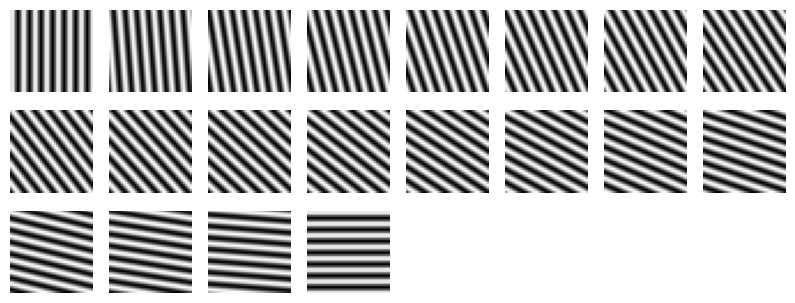

In [3]:
canvas_size = [36, 36]
locations = [[18, 18]]  # center position
sizes_total = [36]  # total size (center + surround)
sizes_center = [0.5]  # portion of radius used for center circle
sizes_surround = [0.5]  # defines the starting portion of radius for surround
contrasts_center = [1.0]  # try 2 center contrasts
contrasts_surround = [1.0]  # surround contrast
orientations_center = list(np.linspace(0, np.pi / 2, 20))
orientations_surround = list(np.linspace(0, np.pi / 2, 20))  # center only
spatial_frequencies_center = [0.2]  # fixed spatial frequency
phases_center = [np.pi]  # center phases
grey_levels = [0.0]  # fixed grey level
# spatial_frequencies_surround = [0.1, 0.3]  # optional parameter, default: same as spatial_frequencies_center
# phases_surround = [np.pi/4]                # optional parameter, default: same as phases_center

center_surround = CenterSurround(
    canvas_size=canvas_size,
    locations=locations,
    sizes_total=sizes_total,
    sizes_center=sizes_center,
    sizes_surround=sizes_surround,
    contrasts_center=contrasts_center,
    contrasts_surround=contrasts_surround,
    orientations_center=orientations_center,
    orientations_surround=orientations_surround,
    spatial_frequencies_center=spatial_frequencies_center,
    phases_center=phases_center,
    grey_levels=grey_levels,
)

# gratings_offset = 0.5
gratings = np.array(
    [
        center_surround.images()[idx]
        for idx in range(len(center_surround.images()))
        if center_surround.params_dict_from_idx(idx)["orientation_center"]
        == center_surround.params_dict_from_idx(idx)["orientation_surround"]
    ]
)
plt.figure(figsize=(10, 5))
for i, img in enumerate(gratings):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
    plt.axis("off")

In [4]:
G_prob = 1 / len(gratings)
x_sigma = 0.1
I_sigma = 1
gratings_offset = 0.0

model = HierarchicalGratingModel(
    gratings=gratings,
    G_prob=G_prob,
    X_sigma=x_sigma,
    I_sigma=I_sigma,
    gratings_offset=gratings_offset,
)

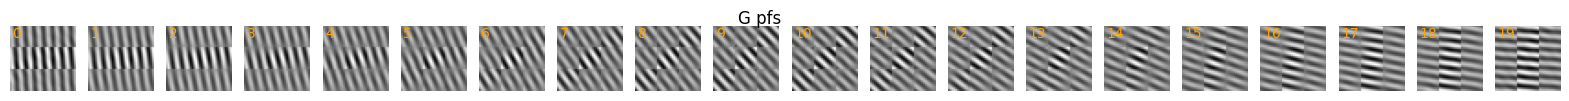

In [5]:
model.visualize_learned_G(nrows=1, ncols=len(gratings))

(-0.5, 179.5, 19.5, -0.5)

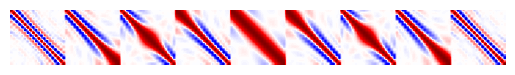

In [8]:
plt.imshow(model.G_X_mapping.T, cmap="seismic", vmin=-1, vmax=1)
plt.axis("off")
# plt.colorbar()

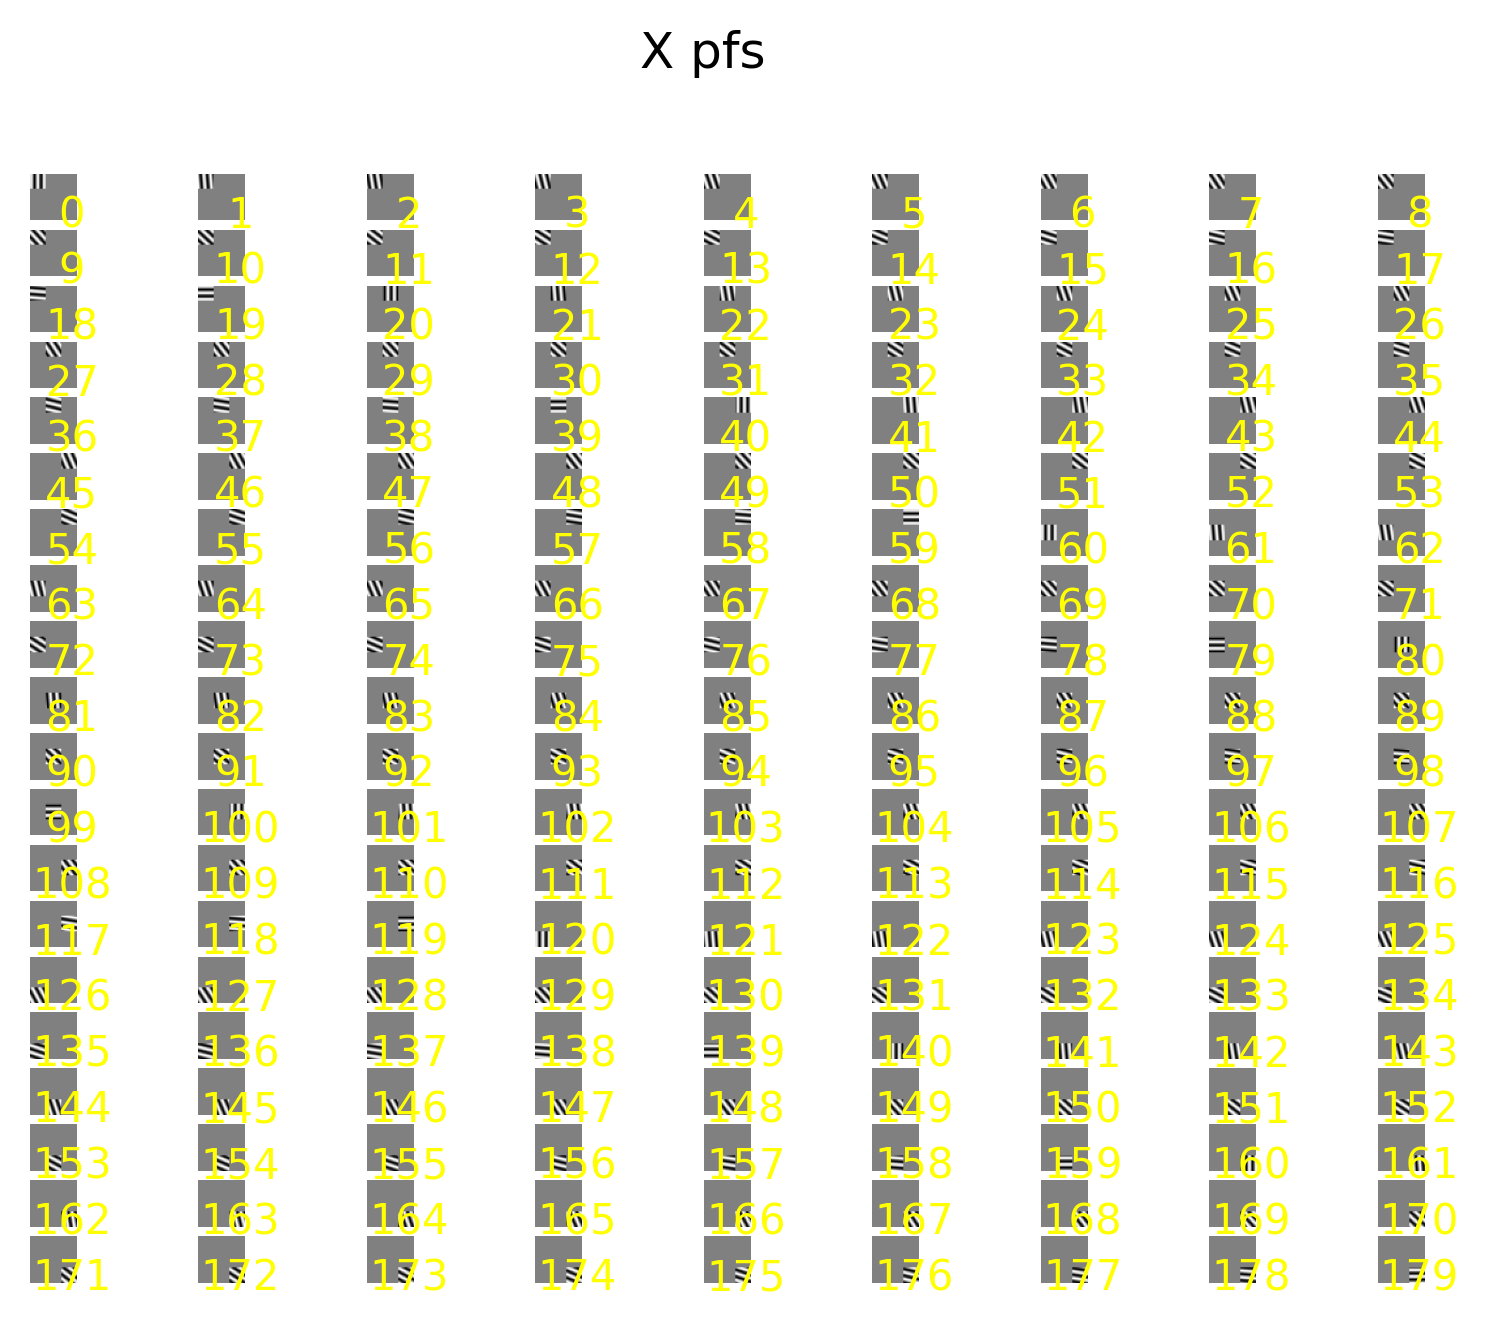

In [7]:
model.visualize_learned_X(nrows=20, ncols=9)

(-0.5, 35.5, 35.5, -0.5)

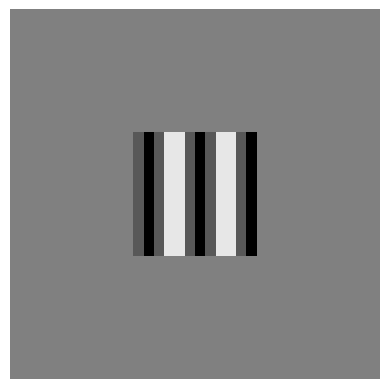

In [11]:
empty_image = np.zeros((36, 36))
MEI_center = model.grating_crops[4][0].reshape(12, 12).copy()
empty_image[12:24, 12:24] = MEI_center
MEI = empty_image
plt.imshow(MEI, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 35.5, 35.5, -0.5)

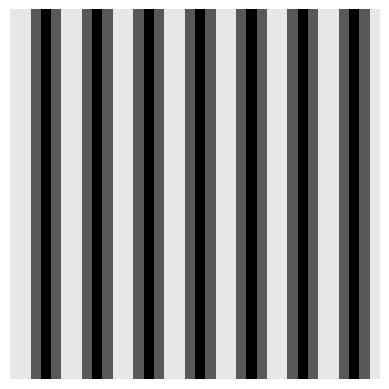

In [12]:
completing_image = model.gratings[0].copy()
plt.imshow(completing_image, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 35.5, 35.5, -0.5)

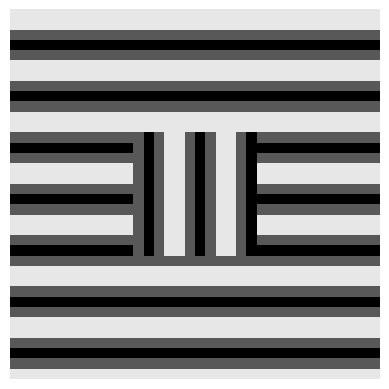

In [14]:
disrupting_image_1 = model.gratings[-1].copy()
disrupting_image_1[12:24, 12:24] = MEI_center.copy()
plt.imshow(disrupting_image_1, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [15]:
images = [MEI, completing_image, disrupting_image_1]
n_samples = 1000
n_tune = 1000
all_samples = []
for image in images:
    post_samples = model.sample_posterior(
        image=image, n_samples=n_samples, random_seed=42, tune=n_tune, chains=4, cores=4
    )
    all_samples.append(post_samples)

reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 602 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 628 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 579 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


In [17]:
n_neurons = 20 * 9
all_x_samples_reshaped = []
for samples in all_samples:
    samples = samples["posterior"]["X"].data.reshape(4 * n_samples, n_neurons)
    all_x_samples_reshaped.append(samples)

In [18]:
all_x_samples_reshaped = np.array(all_x_samples_reshaped)
print(all_x_samples_reshaped.shape)

(3, 4000, 180)


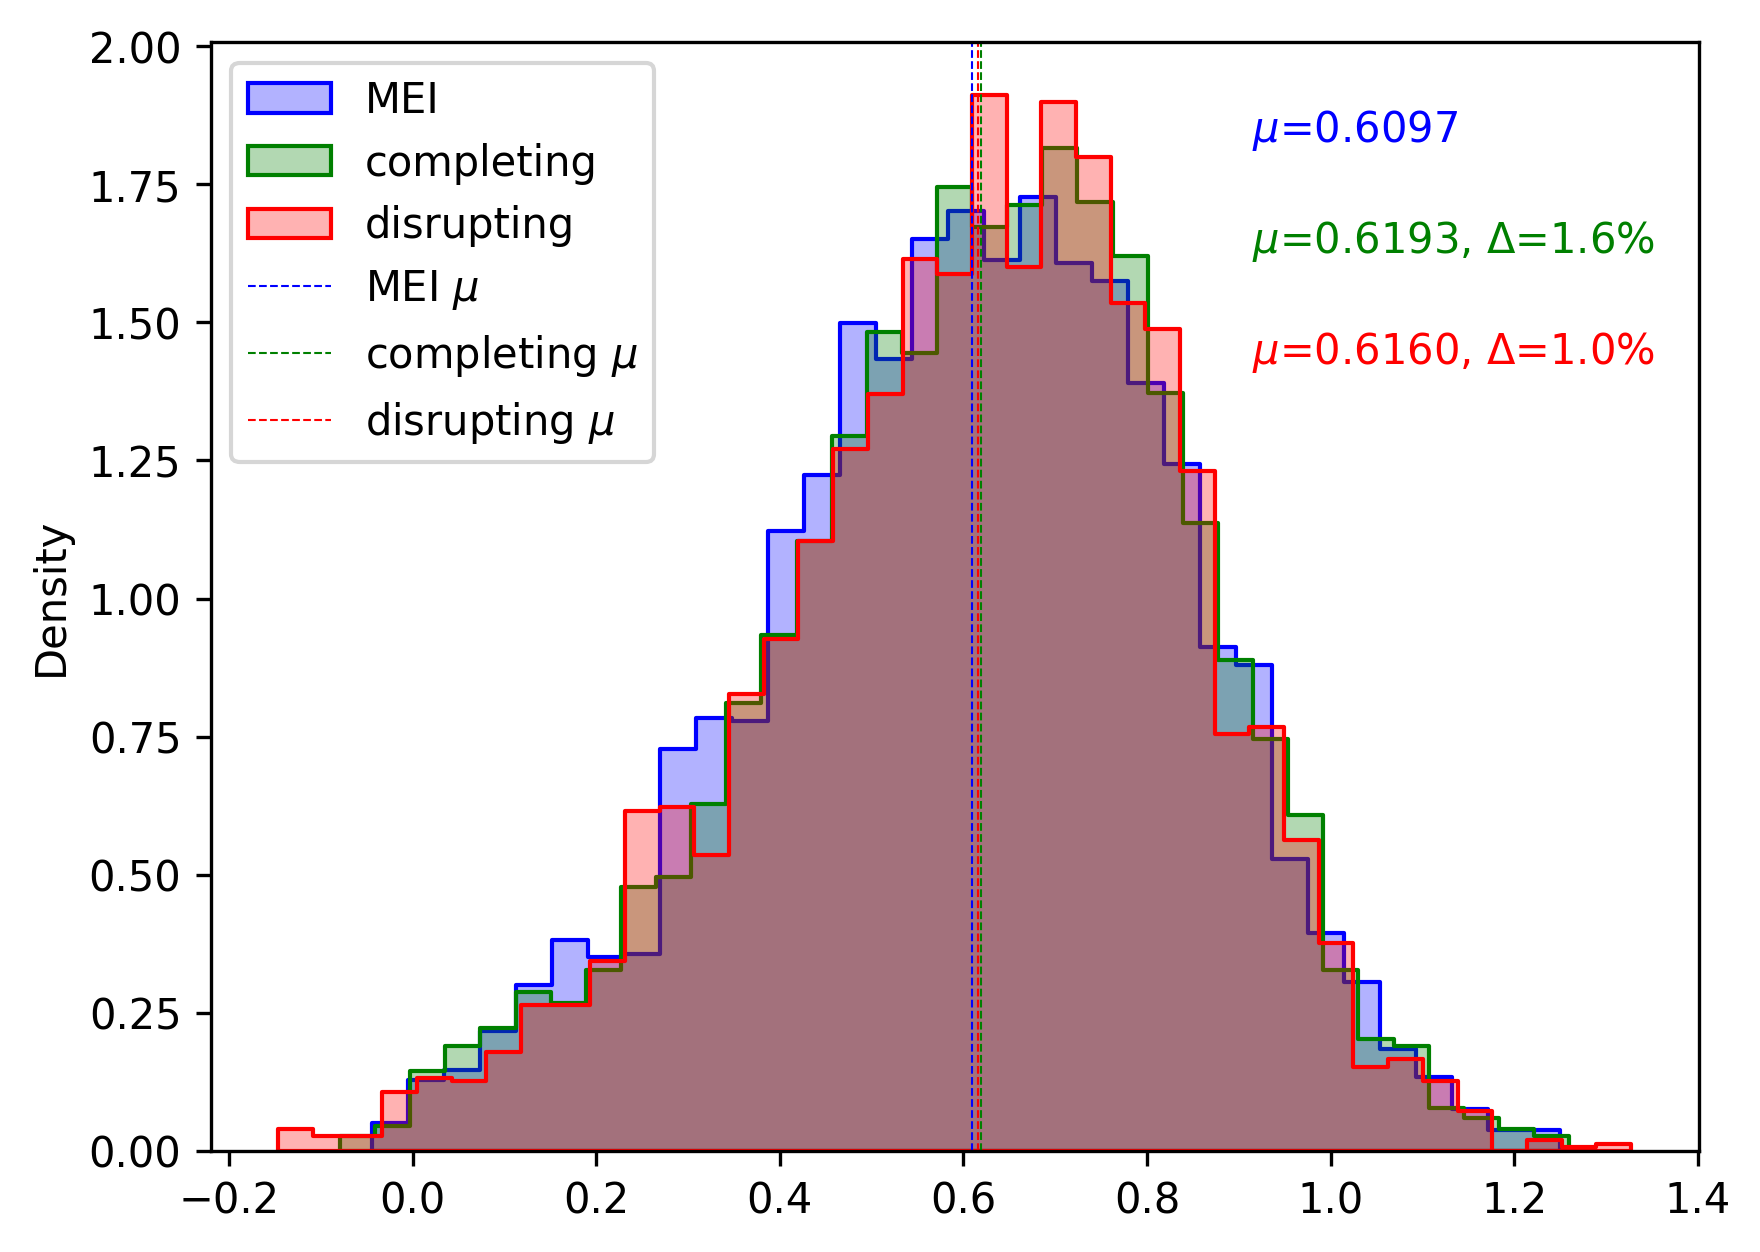

In [19]:
fig, ax = plt.subplots(dpi=300)
neuron_id = 80
sns.histplot(
    all_x_samples_reshaped[0][:, neuron_id],
    ax=ax,
    stat="density",
    color="blue",
    element="step",
    alpha=0.3,
    label="MEI",
)
sns.histplot(
    all_x_samples_reshaped[1][:, neuron_id],
    ax=ax,
    stat="density",
    color="green",
    element="step",
    alpha=0.3,
    label="completing",
)
sns.histplot(
    all_x_samples_reshaped[2][:, neuron_id],
    ax=ax,
    stat="density",
    color="red",
    element="step",
    alpha=0.3,
    label="disrupting",
)

MEI_mean = np.mean(all_x_samples_reshaped[0][:, neuron_id])
completing_mean = np.mean(all_x_samples_reshaped[1][:, neuron_id])
disrupting_mean = np.mean(all_x_samples_reshaped[2][:, neuron_id])
completing_perc_change = (completing_mean - MEI_mean) / MEI_mean
disrupting_perc_change = (disrupting_mean - MEI_mean) / MEI_mean

ax.text(
    0.7,
    0.9,
    f"$\mu$={MEI_mean:.4f}",
    size=10,
    ha="left",
    va="bottom",
    transform=ax.transAxes,
    color="blue",
)
ax.text(
    0.7,
    0.8,
    f"$\mu$={completing_mean:.4f}, $\Delta$={completing_perc_change*100:.1f}%",
    size=10,
    ha="left",
    va="bottom",
    transform=ax.transAxes,
    color="green",
)
ax.text(
    0.7,
    0.7,
    f"$\mu$={disrupting_mean:.4f}, $\Delta$={disrupting_perc_change*100:.1f}%",
    size=10,
    ha="left",
    va="bottom",
    transform=ax.transAxes,
    color="red",
)

ax.axvline(MEI_mean, color="blue", linestyle="--", linewidth=0.5, label="MEI $\mu$")
ax.axvline(
    completing_mean,
    color="green",
    linestyle="--",
    linewidth=0.5,
    label="completing $\mu$",
)
ax.axvline(
    disrupting_mean,
    color="red",
    linestyle="--",
    linewidth=0.5,
    label="disrupting $\mu$",
)

ax.legend(loc="upper left")

In [20]:
all_samples[0]["posterior"]["G"].data.mean(axis=1)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.]])

In [21]:
all_samples[1]["posterior"]["G"].data.mean(axis=1)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.]])

In [22]:
all_samples[2]["posterior"]["G"].data.mean(axis=1)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.]])